# 9 现代循环神经网络

## 9.1 门控循环单元（GPU）

在循环神经网络中计算梯度可能导致梯度异常的实际意义：



| 问题/场景 | 期望机制/目标 |
| --- | --- |
| 早期观测值对预测所有未来观测值具有非常重要的意义，此时其对应梯度将非常大 | 希望有机制能存储更重要的早期信息 |
| 部分词元与观测值无关 | 希望有一些机制能跳过这些词元 |
| 序列的各个部分存在逻辑中断 | 希望能重置状态表示 |

**门控循环单元（gated recurrent unit，GRU）** 有专门的机制来确定应该何时更新隐状态，以及应该何时重置隐状态，这些机制是可学习的。

#### 重置门与更新门

**重置门（reset gate）** 允许控制可能还要保留的过去状态的数量，有助于捕获序列中的短期依赖关系。

**更新门（update gate）** 允许控制新状态中有多少个是旧状态的副本，有助于捕获序列中的长期依赖关系。



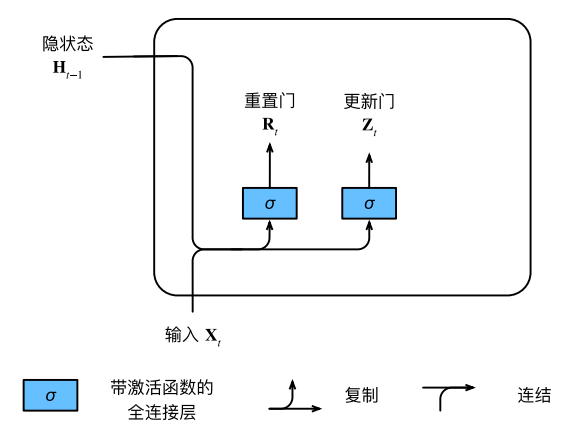

对于给定的时间步 $t$ ，假设输入是一个小批量 $\textbf{X}_t \in \mathbb{R}^{n\times d}$ （样本个数 $n$ ，输入个数 $d$），上一个时间步的隐状态是 $\textbf{H}_{t-1} \in \mathbb{R}^{n\times h}$ （隐藏单元个数 $h$）。那么，重置门 $\textbf{R}_t \in \mathbb{R}^{n\times h}$ 和更新门 $\textbf{Z}_t \in \mathbb{R}^{n\times h}$ 的计算如下：

$$
\mathbf{R}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xr} + \mathbf{H}_{t-1} \mathbf{W}_{hr} + \mathbf{b}_r)
$$

$$
\mathbf{Z}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xz} + \mathbf{H}_{t-1} \mathbf{W}_{hz} + \mathbf{b}_z),
$$

*注：样本个数（batch_size）和输入个数（input_size）：*

*假设我们正在训练一个语言模型，处理一批文本数据：*

*样本个数（batch_size）：指这个小批量中包含的独立样本数量。例如，我们一次处理 32 个句子，那么 `batch_size = 32`。每个句子都是一个独立的训练样本，它们之间没有时间上的依赖关系。*

*输入个数（input_size）：指每个样本在单个时间步上的特征维度。例如，我们用一个 100 维的词向量来表示每个单词，那么 `input_size = 100`。它描述的是单个数据点的信息丰富程度。*


#### 候选隐状态

将重置门 $\mathbf{R}_t$ 与常规隐状态更新机制集成，得到在时间步 $t$ 的 **候选隐状态（candidate hidden state）** $\tilde{\mathbf{H}}_t \in \mathbb{R}^{n\times h}$ ：

$$
\tilde{\mathbf{H}}_t = \tanh\left(\mathbf{X}_t \mathbf{W}_{xh} + (\mathbf{R}_t \odot \mathbf{H}_{t-1}) \mathbf{W}_{hh} + \mathbf{b}_h\right)
$$

| 重置门状态 | 对应效果 |
| --- | --- |
| 以往状态重要 | 重置门中的对应项接近1；候选隐状态等同于 8.4 中的普通循环层的输出 |
| 以往状态不重要 | 重置门中的对应项接近0；候选隐状态将没有 $\mathbf{H}_{t-1}$ 的影响，达到重置效果 |

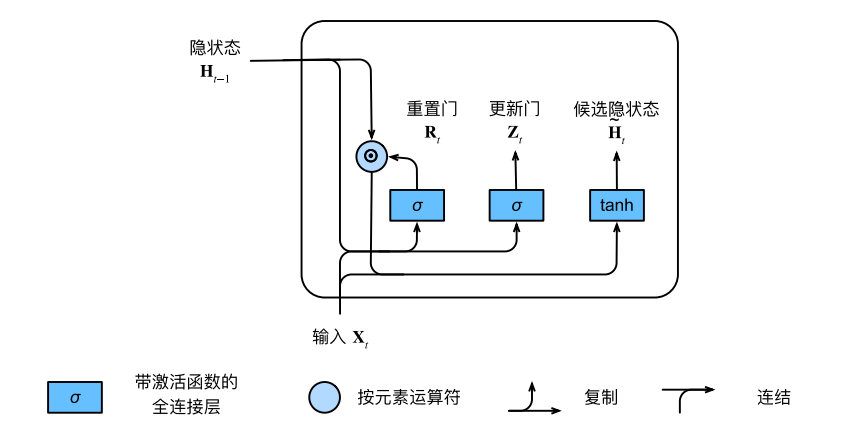

#### 隐状态

更新门 $\mathbf{Z}_t$ 使用 **凸组合** 确定新的隐状态 $H_t \in \mathbb{R}^{n\times h}$ 在多大程度上来自旧的状态 $\mathbf{H}_{t-1}$ 和新的候选状态 $\tilde{\mathbf{H}}_{t}$ ：

$$
\mathbf{H}_t = \mathbf{Z}_t \odot \mathbf{H}_{t-1} + (1 - \mathbf{Z}_t) \odot \tilde{\mathbf{H}}_t.
$$

每当更新门 $\mathbf{Z}_t$ 接近1时，模型就倾向只保留旧状态。此时，来自 $\mathbf{X}_t$ 的信息基本上被忽略，从而有效地跳过了依赖链条中的时间步 $t$。

相反，当 $\mathbf{Z}_t$ 接近0时，新的隐状态 $\mathbf{H}_t$ 就会接近候选隐状态 $\tilde{\mathbf{H}}_t$。这些设计可以帮助我们处理循环神经网络中的梯度消失问题，并更好地捕获时间步距离很长的序列的依赖关系。

#### 代码实现

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [ ]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size
    
    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xz, W_hz, b_z = three() # 更新门参数
    W_xr, W_hr, b_r = three() # 重置门参数
    W_xh, W_hh, b_h = three() # 候选隐状态参数
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params



In [5]:
def init_gru_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

门控循环单元模型的定义如下：

In [3]:
def gru(inputs, state, params):
    W_xz, W_hz, b_z, W_xr, W_hr, b_r, W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    for X in inputs:
        Z = torch.sigmoid((X @ W_xz) + (H @ W_hz) + b_z)
        R = torch.sigmoid((X @ W_xr) + (H @ W_hr) + b_r)
        H_tilda = torch.tanh((X @ W_xh) + ((R * H) @ W_hh) + b_h)
        H = Z * H + (1 - Z) * H_tilda
        Y = H @ W_hq + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

perplexity 1.1, 11919.1 tokens/sec on cpu
time traveller with a slight accession ofcheerfulness really thi
travelleryou can show black is white by argument said filby


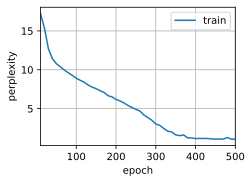

In [6]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_params,
                            init_gru_state, gru)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

`nn.GRU` 是 Pytorch 中的 `torch.nn` 模块提供的标准循环神经网络层之一，专门用于实现 **门控循环单元（Gated Recurrent Unit）** 。 

```python
gru = nn.GRU(
    input_size=100,   # 输入特征维度
    hidden_size=256,  # 隐藏状态维度
    num_layers=2,     # 堆叠层数
    batch_first=True, # 输入/输出格式为 (batch, seq, feature)
    bidirectional=False
)
```

## 9.2 长短期记忆网络（LSTM）

长短期记忆网络的设计与门控循环单元相似但更复杂。它设计了 输入门、忘记门、输出门，同时引入了 候选记忆元 和 记忆元。**记忆元（memory cell）** 用于记录附加的信息。

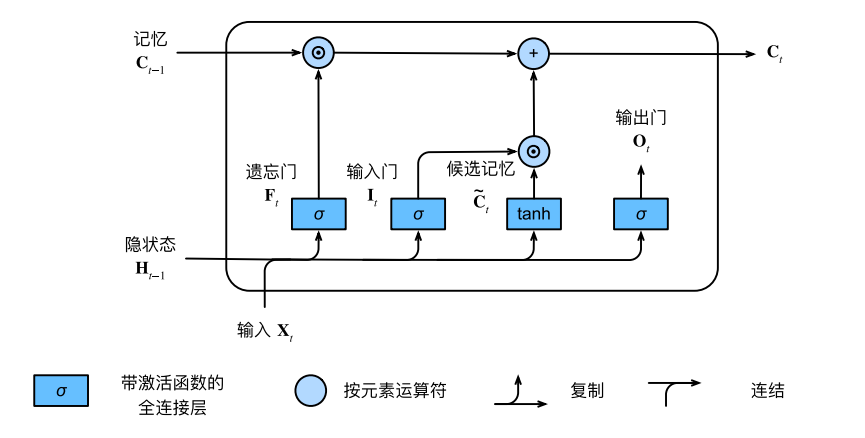

简言之：

长短期记忆网络引入了新的类似隐状态的量，叫记忆元。上一步的记忆元 $\mathbf{C}_{t-1}$ 对这一时间步的记忆元产生影响：

- 遗忘门 $\mathbf{F}_t$ 控制保留多少过去的记忆元的内容

同时，这一时间步内的输入和上一步的隐状态将通过操作生成候选记忆元 $\tilde{\mathbf{C}}_t$ ，而候选记忆元与过去的记忆元将进行组合：

- 输入门 $\mathbf{I}_t$ 控制采用多少来自候选记忆元的新数据

最后得到的记忆元又需要和输入共同得到新的隐状态：

$$
\begin{cases}
\mathbf{I}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xi} + \mathbf{H}_{t-1} \mathbf{W}_{hi} + \mathbf{b}_i), \\
\mathbf{F}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xf} + \mathbf{H}_{t-1} \mathbf{W}_{hf} + \mathbf{b}_f), \\
\mathbf{O}_t = \sigma(\mathbf{X}_t \mathbf{W}_{xo} + \mathbf{H}_{t-1} \mathbf{W}_{ho} + \mathbf{b}_o),
\end{cases}
$$

$$
\begin{cases}
\tilde{\mathbf{C}}_t = \tanh\left(\mathbf{X}_t \mathbf{W}_{xc} + \mathbf{H}_{t-1} \mathbf{W}_{hc} + \mathbf{b}_c\right), \\
\mathbf{C}_t = \mathbf{F}_t \odot \mathbf{C}_{t-1} + \mathbf{I}_t \odot \tilde{\mathbf{C}}_t, \\
\mathbf{H}_t = \mathbf{O}_t \odot \tanh(\mathbf{C}_t).
\end{cases}
$$

## 9.3 深度循环神经网络

将多层循环神经网络堆叠到一起，如图：

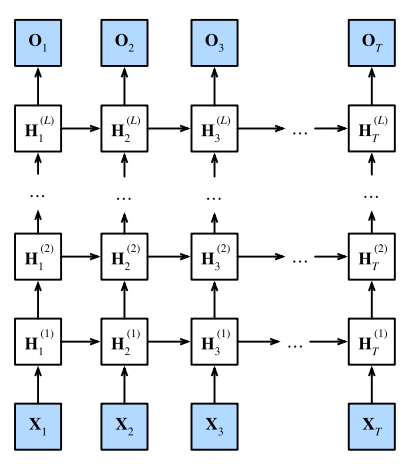

*注：拓扑结构*

假设在时间步 $t$ 有一个小批量的输入数据 $\mathbf{X}_t \in \mathbb{R}^{n \times d}$（样本数：$n$，每个样本中的输入数：$d$）。同时，将第 $l$ 个隐藏层（$l = 1, \dots, L$）的隐状态设为 $\mathbf{H}_t^{(l)} \in \mathbb{R}^{n \times h}$（隐藏单元数：$h$），输出层变量设为 $\mathbf{O}_t \in \mathbb{R}^{n \times q}$（输出数：$q$）。

设置 $\mathbf{H}_t^{(0)} = \mathbf{X}_t$，第 $l$ 个隐藏层的隐状态使用激活函数 $\phi_l$，则：

$$
\mathbf{H}_t^{(l)} = \phi_l\left(\mathbf{H}_t^{(l-1)} \mathbf{W}_{xh}^{(l)} + \mathbf{H}_{t-1}^{(l)} \mathbf{W}_{hh}^{(l)} + \mathbf{b}_h^{(l)}\right)
$$

其中，权重 $\mathbf{W}_{xh}^{(l)} \in \mathbb{R}^{h \times h}$，$\mathbf{W}_{hh}^{(l)} \in \mathbb{R}^{h \times h}$ 和偏置 $\mathbf{b}_h^{(l)} \in \mathbb{R}^{1 \times h}$ 都是第 $l$ 个隐藏层的模型参数。

最后，输出层的计算仅基于第 $l$ 个隐藏层最终的隐状态：

$$
\mathbf{O}_t = \mathbf{H}_t^{(L)} \mathbf{W}_{hq} + \mathbf{b}_q
$$

其中，权重 $\mathbf{W}_{hq} \in \mathbb{R}^{h \times q}$ 和偏置 $\mathbf{b}_q \in \mathbb{R}^{1 \times q}$ 都是输出层的模型参数。

## 9.4 双向循环神经网络

在部分情景下，下文和上文同样重要。

#### 隐马尔可夫模型中的动态规划

在 8.1 中讲到了马尔可夫模型。加入隐状态后，得到了隐马尔可夫模型：


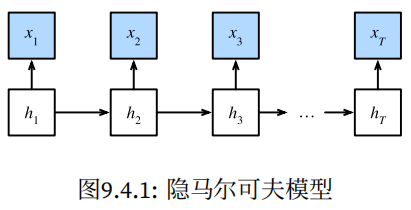

#### 双向模型

**双向循环神经网络（bidirectional RNNs）** 添加了反向传递信息的隐藏层，以便更灵活地处理此类信息。

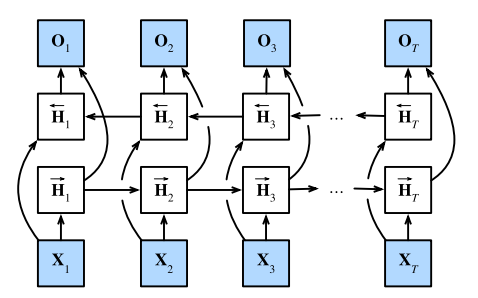

对于任意时间步 $t$，给定一个小批量的输入数据 $\mathbf{X}_t \in \mathbb{R}^{n \times d}$（样本数 $n$，每个示例中的输入数 $d$），并且令隐藏层激活函数为 $\phi$。在双向架构中，我们设该时间步的前向和反向隐状态分别为 $\overrightarrow{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$ 和 $\overleftarrow{\mathbf{H}}_t \in \mathbb{R}^{n \times h}$，其中 $h$ 是隐藏单元的数目。前向和反向隐状态的更新如下：

$$
\begin{aligned}
\overrightarrow{\mathbf{H}}_t &= \phi\left(\mathbf{X}_t \mathbf{W}_{xh}^{(f)} + \overrightarrow{\mathbf{H}}_{t-1} \mathbf{W}_{hh}^{(f)} + \mathbf{b}_h^{(f)}\right), \\
\overleftarrow{\mathbf{H}}_t &= \phi\left(\mathbf{X}_t \mathbf{W}_{xh}^{(b)} + \overleftarrow{\mathbf{H}}_{t+1} \mathbf{W}_{hh}^{(b)} + \mathbf{b}_h^{(b)}\right),
\end{aligned}
$$

其中，权重 $\mathbf{W}_{xh}^{(f)} \in \mathbb{R}^{d \times h}$，$\mathbf{W}_{hh}^{(f)} \in \mathbb{R}^{h \times h}$，$\mathbf{W}_{xh}^{(b)} \in \mathbb{R}^{d \times h}$，$\mathbf{W}_{hh}^{(b)} \in \mathbb{R}^{h \times h}$ 和偏置 $\mathbf{b}_h^{(f)} \in \mathbb{R}^{1 \times h}$，$\mathbf{b}_h^{(b)} \in \mathbb{R}^{1 \times h}$ 都是模型参数。

接下来，将前向隐状态 $\overrightarrow{\mathbf{H}}_t$ 和反向隐状态 $\overleftarrow{\mathbf{H}}_t$ 连接起来，获得需要送入输出层的隐状态 $\mathbf{H}_t \in \mathbb{R}^{n \times 2h}$。在具有多个隐藏层的深度双向循环神经网络中，该信息作为输入传递到下一个双向层。最后，输出层计算得到的输出为 $\mathbf{O}_t \in \mathbb{R}^{n \times q}$（$q$ 是输出单元的数目）：

$$
\mathbf{O}_t = \mathbf{H}_t \mathbf{W}_{hq} + \mathbf{b}_q
$$

这里，权重矩阵 $\mathbf{W}_{hq} \in \mathbb{R}^{2h \times q}$ 和偏置 $\mathbf{b}_q \in \mathbb{R}^{1 \times q}$ 是输出层的模型参数。事实上，这两个方向可以拥有不同数量的隐藏单元。

双向循环神经网络存在两个问题：

- 在训练期间，我们能够利用过去和未来的数据来估计现在空缺的词；而在测试期间，我们只有过去的数据，因此精度将会很差

- 是网络的前向传播需要在双向层中进行前向和后向递归，并且网络的反向传播还依赖于前向传播的结果，计算速度非常慢

## 9.5 机器翻译

**机器翻译（machine translation）** 指的是将序列从一种语言自动翻译成另一种语言。基于神经网络的方法通常称为 神经机器翻译 。

在这一类问题的文本预处理过程中，数据集处理将进过更多的步骤，词元化更喜欢单词级词元化，最先进的模型可能使用更高级的词元化技术。此时词表大小将明显大于使用字符级词元化时的词表大小。

*注：*

*在中文、日语等无空格语言中，**子词级词元化（如 BPE、WordPiece、SentencePiece）** 已成为主流选择，它兼顾了单词的语义性和字符的细粒度。*

*它的核心逻辑是：将文本拆分为 “高频完整词 + 低频子词 / 字符” 的组合。这里的 “子词” 是具有语义关联性的最小单元—— 既不是完整的单词，也不是孤立的字符，而是能表达部分语义、可灵活组合的片段。*

#### 编码器-解码器架构

机器翻译是序列转换模型的一个核心问题，其输入和输出都是长度可变的序列。为了处理这种类型的输入和输出，可以设计一个包含两个主要组件的架构：

- **编码器（encoder）** ：接受一个长度可变的序列作为输入，并将其转换为具有固定形状的编码状态
- **解码器（decoder）** ：将固定形状的编码状态映射到长度可变的序列



#### 序列到序列学习（seq2seq）

使用循环神经网络作为编码器和解码器。

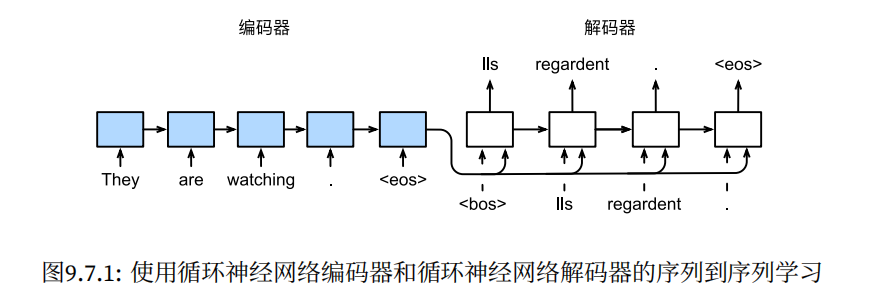

**编码器** ：

作用是**读入并理解长度可变的输入序列**，将其信息压缩为一个**固定形状的上下文向量（或隐状态）** ：
- 输入：变长的源序列（比如英文句子的词元序列，末尾加 `<eos>` 表示序列结束）。
- 处理：通过循环神经网络（RNN/GRU/LSTM）+ 嵌入层，逐词处理输入序列，每个时间步更新隐状态，最终把整个序列的信息汇总到**最后一个时间步的隐状态**中（也可以用所有时间步的隐状态）。
- 输出：上下文向量（编码器的最终隐状态）


**解码器** ：

作用是**基于编码器的上下文，逐词生成长度可变的输出序列** ：
- 输入：
  1.  编码器输出的上下文向量（每个时间步都和输入拼接，让解码器始终知道输入信息）；
  2.  已经生成的输出词元（训练时用真实标签，预测时用上一步的预测结果），开头加 `<bos>` 表示序列开始。
- 处理：通过循环神经网络 + 全连接层，逐词更新隐状态，然后用 softmax 输出下一个词元的概率分布。
- 输出：每个时间步预测一个词元，直到生成 `<eos>` 时停止，得到完整输出序列。



**强制教学（Teacher Forcing）** ：

训练时，解码器的输入**不是上一步的预测结果**，而是**真实的标签序列**（开头拼接 `<bos>`，结尾去掉 `<eos>`）。
- 目的：避免早期预测错误累积，让训练更稳定、收敛更快。



**BLEU 指标** ：

生成序列的质量用 **BLEU（bilingual evaluation understudy）** 衡量，核心逻辑是：
- 统计预测序列和真实标签序列中，**n-gram（连续n个词元）的匹配度**；
- 同时惩罚过短的生成结果，避免模型只生成少量词就结束；
- 取值范围 0~1，越接近 1 说明生成结果和真实标签越相似。


$$
\exp\left( \min\left(0, 1 - \frac{\text{len}_{\text{label}}}{\text{len}_{\text{pred}}}\right) \right) \prod_{n=1}^k p_n^{1/2^n},
$$


## 9.8 束搜索



上面讲到，解码器通过循环神经网络 + 全连接层，逐词更新隐状态，然后用 softmax 输出下一个词元的概率分布，再每个时间步预测词元。

- 贪心搜索：在每个时间步都输出具有最高条件概率的词元，这显然不能保证得到最优序列
- 穷举搜索：穷举地列举所有可能的输出序列及其条件概率，然后计算输出条件概率最高的一个，这需要极高的计算量

束搜索（beam search）是贪心搜索的一个改进版本。它有一个超参数，名为**束宽（beam size）** $k$：

- 在时间步1，我们选择具有最高条件概率的 $k$ 个词元，这 $k$ 个词元将分别是 $k$ 个候选输出序列的第一个词元。
- 在随后的每个时间步，基于上一时间步的 $k$ 个候选输出序列，我们将继续从 $k|\mathcal{V}|$ 个可能的选择中（$|\mathcal{V}|$ 为词表大小），挑出具有最高条件概率的 $k$ 个候选输出序列。


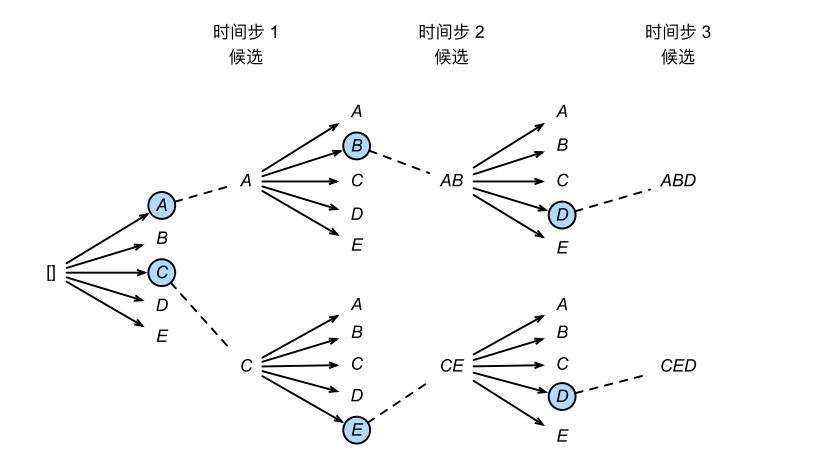